# 01 — Telco basic exploratory data analysis

**Objective:** Understand what one row represents, inspect the columns and missing values, and describe the churn target before attempting to build a model. Each row is one customer, and `Churn` records whether that customer left the company.

## Load the data

We load the course dataset with pandas. The shape is calculated from the CSV so that the reported number of customers and columns always reflects the data being used.

In [1]:
# Use Path so the relative data location is explicit and works across operating systems.
from pathlib import Path

# Import Matplotlib to create figures and control titles, labels, and sizes.
import matplotlib.pyplot as plt
# Import pandas to load the CSV and inspect tabular data.
import pandas as pd
# Import seaborn for clear statistical plots built on Matplotlib.
import seaborn as sns

# Point from the notebooks folder to the course dataset stored in the repository.
data_path = Path("../data/telco.csv")
# Load one CSV row per customer into a DataFrame for inspection.
df = pd.read_csv(data_path)

In [2]:
# Display the first five customers to check the values and column meanings.
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
# Return (rows, columns) to establish the size of the dataset before analysis.
df.shape

(7043, 21)

In [4]:
# Turn the shape into a sentence so the observation unit and feature count are explicit.
print(f"The dataset contains {df.shape[0]:,} customers and {df.shape[1]} columns.")

The dataset contains 7,043 customers and 21 columns.


## Basic inspection

`info()` shows column names, data types, and non-missing counts. `describe()` summarizes the columns that pandas currently recognizes as numeric.

In [5]:
# Inspect data types and non-missing counts to identify parsing or completeness issues.
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [6]:
# Summarize numeric columns to check their ranges and typical values.
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


The target counts show how many customers churned. The normalized counts express the same result as proportions.

In [7]:
# Count each target class to see how many customers stayed and churned.
df["Churn"].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [8]:
# Normalize the counts to proportions so class imbalance is easy to compare.
df["Churn"].value_counts(normalize=True)

Churn
No     0.73463
Yes    0.26537
Name: proportion, dtype: float64

### Parse `TotalCharges`

`TotalCharges` was loaded as text because some records contain only whitespace. A blank charge is missing information, not a charge of zero. Converting with `errors="coerce"` turns those blanks into `NaN` while preserving valid numbers.

In [9]:
# Remove surrounding whitespace temporarily, mark empty strings, and count them.
blank_total_charges = df["TotalCharges"].str.strip().eq("").sum()
# Report the issue before changing the column so the cleaning decision is auditable.
print(f"Whitespace-only TotalCharges values: {blank_total_charges}")

Whitespace-only TotalCharges values: 11


In [10]:
# Parse valid charge strings as numbers and convert invalid blanks to missing values.
df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],  # Parse the original text column.
    errors="coerce"  # Represent non-numeric blanks as NaN rather than as zero.
)

# Confirm that the eleven blank source values are now explicit missing values.
print(f"Missing TotalCharges values after parsing: {df['TotalCharges'].isna().sum()}")

Missing TotalCharges values after parsing: 11


We leave these values missing in this exploratory notebook. Imputation would introduce an estimated replacement and belongs inside the later modelling workflow.

## Four focused visualizations

The first chart makes the target imbalance visible.

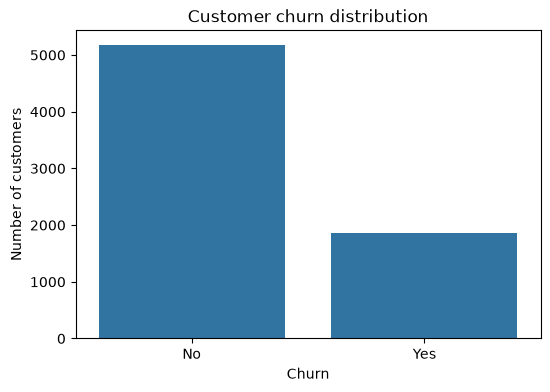

In [11]:
# Create a compact canvas so the chart remains readable inside the notebook.
plt.figure(figsize=(6, 4))
# Count customers in each target class and keep the business order No, then Yes.
sns.countplot(data=df, x="Churn", order=["No", "Yes"])
# State the question answered by the chart.
plt.title("Customer churn distribution")
# Label the horizontal axis with the observed outcome.
plt.xlabel("Churn")
# Label the vertical axis with the quantity being counted.
plt.ylabel("Number of customers")
# Render the completed figure in this output cell.
plt.show()

The tenure histogram shows how long customers in this dataset have stayed with the company.

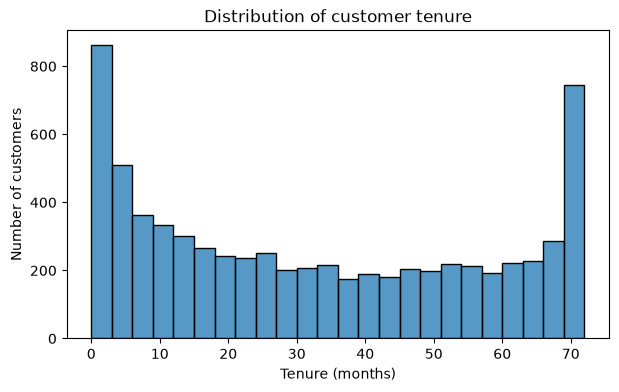

In [12]:
# Create a wide canvas for the tenure distribution.
plt.figure(figsize=(7, 4))
# Group tenure into 24 bins to show its overall shape without listing every month.
sns.histplot(data=df, x="tenure", bins=24)
# State which customer characteristic the distribution describes.
plt.title("Distribution of customer tenure")
# Include the unit because tenure is measured in months.
plt.xlabel("Tenure (months)")
# Clarify that bar heights count customers.
plt.ylabel("Number of customers")
# Render the completed figure in this output cell.
plt.show()

A boxplot lets us compare the distribution of monthly charges between customers who stayed and customers who churned.

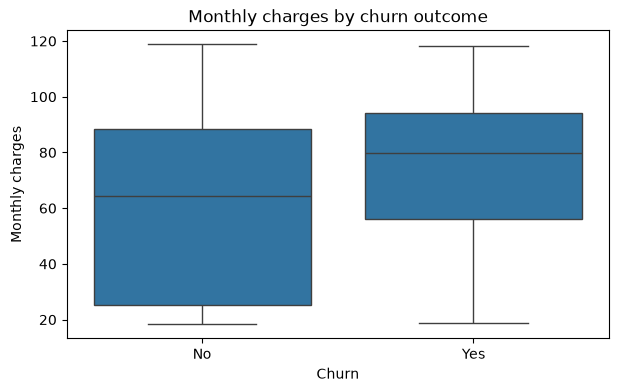

In [13]:
# Create a wide canvas for comparing the two target groups.
plt.figure(figsize=(7, 4))
# Compare charge distributions while preserving the No/Yes target order.
sns.boxplot(data=df, x="Churn", y="MonthlyCharges", order=["No", "Yes"])
# State the relationship shown by the plot.
plt.title("Monthly charges by churn outcome")
# Label each group by its observed churn outcome.
plt.xlabel("Churn")
# Identify the numeric quantity summarized by each box.
plt.ylabel("Monthly charges")
# Render the completed figure in this output cell.
plt.show()

Finally, we calculate the churn proportion within each contract type. Normalizing by row makes contract groups of different sizes comparable.

In [14]:
# Calculate the churn distribution separately within each contract type.
contract_table = pd.crosstab(
    df["Contract"],  # Use one row for each contract category.
    df["Churn"],  # Use one column for each observed churn outcome.
    normalize="index"  # Divide each row by its total to compare proportions.
)
# Display both the churn and non-churn proportions before plotting one of them.
contract_table

Churn,No,Yes
Contract,,
Month-to-month,0.572903,0.427097
One year,0.887305,0.112695
Two year,0.971681,0.028319


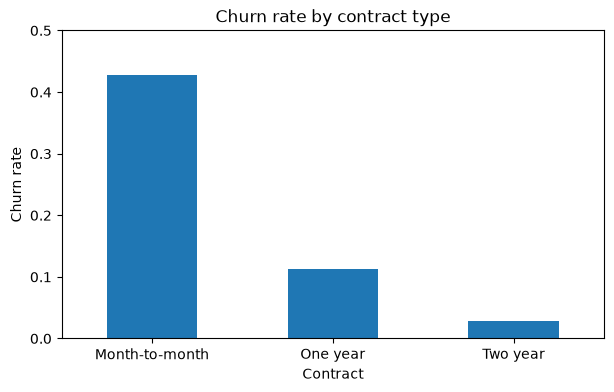

In [15]:
# Select the Yes proportion and sort it so the highest churn rate appears first.
contract_churn_rate = contract_table["Yes"].sort_values(ascending=False)

# Create a wide canvas for the three contract categories.
plt.figure(figsize=(7, 4))
# Draw one bar per contract using the calculated churn proportions.
contract_churn_rate.plot(kind="bar")
# State the comparison made by the chart.
plt.title("Churn rate by contract type")
# Label the categories represented by the bars.
plt.xlabel("Contract")
# Make clear that the vertical values are proportions, not customer counts.
plt.ylabel("Churn rate")
# Use a common zero-to-50% scale so bar heights are not visually exaggerated.
plt.ylim(0, 0.5)
# Keep the short contract labels horizontal for easy reading.
plt.xticks(rotation=0)
# Render the completed figure in this output cell.
plt.show()

## What did we learn?

- The dataset contains 7,043 customers and 21 columns, including the identifier and target.
- Eleven `TotalCharges` entries are blank and become missing numeric values; they should not be treated as zero.
- About 26.5% of customers churned, compared with 73.5% who did not.
- Churn is most common among month-to-month customers in this dataset.

A model that predicts **No churn** for everyone already achieves relatively high accuracy, so accuracy alone cannot tell us whether a solution is useful.